# Internet Connection Quality Monitor

This notebook measures two kinds of connection quality over time:

- frequent TCP "ping" samples, which measure how quickly a connection can open a socket to stable internet endpoints
- slower download/upload probes, which estimate throughput without running a full speed test constantly

Use it in one of two modes:

- **Sequential:** connect to network A, run a session, switch to network B, run another session, then compare the saved CSV files.
- **Parallel:** keep both networks active at once and set each connection's `source_ip` so traffic is bound to the intended interface.

Note: this uses TCP connect latency instead of ICMP ping so it works without sudo/root permissions and can bind to a source IP more reliably from Python.

In [52]:
%pip install -q aiohttp pandas matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [53]:
%pip install --upgrade pip
%pip install aiohttp pandas matplotlib ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://artifacts-prod-use1.pinadmin.com/artifactory/api/pypi/pinterest-python-pip-prod-virtual/simple/
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://artifacts-prod-use1.pinadmin.com/artifactory/api/pypi/pinterest-python-pip-prod-virtual/simple/
Note: you may need to restart the kernel to use updated packages.


In [54]:
import asyncio
import math
import socket
import subprocess
import time
from datetime import datetime, timezone
from pathlib import Path

import aiohttp
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output, display
from matplotlib.backends.backend_pdf import PdfPages

# Google Meet-oriented defaults: measure stability without saturating your connection.
PING_INTERVAL_SECONDS = 0.50      # 2 latency samples/sec/connection
PLOT_REFRESH_SECONDS = 2.0        # redraw chart cadence
SPEED_INTERVAL_SECONDS = 45.0     # capacity probe cadence
TCP_TIMEOUT_SECONDS = 1.5
DOWNLOAD_BYTES = 4_000_000        # 4 MB per download probe, enough for a useful Mbps estimate
UPLOAD_BYTES = 1_500_000          # 1.5 MB per upload probe, keeps tests less disruptive

# Practical targets for a smooth Google Meet call. More headroom is better.
MEET_TARGET_DOWNLOAD_MBPS = 4.0
MEET_TARGET_UPLOAD_MBPS = 3.2    # Google Meet HD upload target
MEET_TARGET_LATENCY_MS = 150      # RTT-style latency target
MEET_CAUTION_LATENCY_MS = 200
MEET_GOOD_JITTER_MS = 30
MEET_OK_JITTER_MS = 50
MEET_GOOD_LOSS_PCT = 1.0
MEET_OK_LOSS_PCT = 3.0

# Stable endpoints for TCP connect latency. You can add/remove endpoints.
LATENCY_ENDPOINTS = [
    ("meet.google.com", 443, "google_meet"),
    ("www.gstatic.com", 443, "google_static"),
    ("1.1.1.1", 443, "cloudflare"),
    ("8.8.8.8", 443, "google_dns"),
]

SPEED_DOWNLOAD_URL = f"https://speed.cloudflare.com/__down?bytes={DOWNLOAD_BYTES}"
SPEED_UPLOAD_URL = "https://speed.cloudflare.com/__up"

# Fill this out before running.
# If testing sequentially on macOS Wi-Fi, set name to None to auto-detect the SSID.
# If testing in parallel, set source_ip to the IP address for each interface/network.
CONNECTIONS = [
    {"name": None, "source_ip": None},
]

samples = []

In [55]:
def wifi_interfaces():
    """Return macOS device names for Wi-Fi hardware, such as en0 or en1."""
    try:
        result = subprocess.run(
            ["/usr/sbin/networksetup", "-listallhardwareports"],
            check=False,
            capture_output=True,
            text=True,
        )
    except FileNotFoundError:
        return []

    interfaces = []
    current_port_is_wifi = False
    for line in result.stdout.splitlines():
        if line.startswith("Hardware Port:"):
            current_port_is_wifi = "Wi-Fi" in line or "AirPort" in line
        elif current_port_is_wifi and line.startswith("Device:"):
            interfaces.append(line.split(":", 1)[1].strip())
            current_port_is_wifi = False
    return interfaces


def current_wifi_ssid():
    """Return the current macOS Wi-Fi SSID, or None if it cannot be detected."""
    for interface in wifi_interfaces() or ["en0", "en1", "en2"]:
        result = subprocess.run(
            ["/usr/sbin/networksetup", "-getairportnetwork", interface],
            check=False,
            capture_output=True,
            text=True,
        )
        output = (result.stdout or result.stderr).strip()
        prefix = "Current Wi-Fi Network: "
        if output.startswith(prefix):
            return output[len(prefix):]

    return None


def _connection_name(connection):
    name = connection.get("name") or current_wifi_ssid()
    if not name:
        raise ValueError(
            "Could not auto-detect the Wi-Fi SSID from macOS. "
            "Set the connection name manually, for example: "
            "{'name': 'Peanut Butter', 'source_ip': None}."
        )
    return name


def _now_iso():
    return datetime.now(timezone.utc).isoformat()


def _local_addr(source_ip):
    return (source_ip, 0) if source_ip else None


def _connector(source_ip):
    family = socket.AF_INET if source_ip and "." in source_ip else 0
    return aiohttp.TCPConnector(
        local_addr=_local_addr(source_ip),
        family=family,
        ttl_dns_cache=300,
    )


async def tcp_ping_once(connection, endpoint):
    host, port, endpoint_name = endpoint
    started = time.perf_counter()
    try:
        reader, writer = await asyncio.wait_for(
            asyncio.open_connection(
                host,
                port,
                local_addr=_local_addr(connection.get("source_ip")),
            ),
            timeout=TCP_TIMEOUT_SECONDS,
        )
        latency_ms = (time.perf_counter() - started) * 1000
        writer.close()
        await writer.wait_closed()
        error = None
        ok = True
    except Exception as exc:
        latency_ms = math.nan
        error = type(exc).__name__
        ok = False

    return {
        "ts": _now_iso(),
        "unix_ts": time.time(),
        "connection": connection["name"],
        "source_ip": connection.get("source_ip"),
        "metric": "tcp_ping",
        "endpoint": endpoint_name,
        "latency_ms": latency_ms,
        "ok": ok,
        "error": error,
        "mbps": math.nan,
    }


async def measure_download_mbps(connection):
    started = time.perf_counter()
    total = 0
    timeout = aiohttp.ClientTimeout(total=30)
    async with aiohttp.ClientSession(connector=_connector(connection.get("source_ip")), timeout=timeout) as session:
        async with session.get(SPEED_DOWNLOAD_URL) as response:
            response.raise_for_status()
            async for chunk in response.content.iter_chunked(256 * 1024):
                total += len(chunk)
    elapsed = time.perf_counter() - started
    return (total * 8) / elapsed / 1_000_000


async def measure_upload_mbps(connection):
    payload = b"0" * UPLOAD_BYTES
    started = time.perf_counter()
    timeout = aiohttp.ClientTimeout(total=30)
    async with aiohttp.ClientSession(connector=_connector(connection.get("source_ip")), timeout=timeout) as session:
        async with session.post(SPEED_UPLOAD_URL, data=payload) as response:
            response.raise_for_status()
            await response.read()
    elapsed = time.perf_counter() - started
    return (UPLOAD_BYTES * 8) / elapsed / 1_000_000


async def ping_loop(connection, stop_at):
    i = 0
    while time.time() < stop_at:
        loop_started = time.perf_counter()
        endpoint = LATENCY_ENDPOINTS[i % len(LATENCY_ENDPOINTS)]
        samples.append(await tcp_ping_once(connection, endpoint))
        i += 1
        elapsed = time.perf_counter() - loop_started
        await asyncio.sleep(max(0, PING_INTERVAL_SECONDS - elapsed))


async def speed_loop(connection, stop_at):
    await asyncio.sleep(3)
    while time.time() < stop_at:
        for direction, measure in (("download", measure_download_mbps), ("upload", measure_upload_mbps)):
            row = {
                "ts": _now_iso(),
                "unix_ts": time.time(),
                "connection": connection["name"],
                "source_ip": connection.get("source_ip"),
                "metric": direction,
                "endpoint": "cloudflare_speed",
                "latency_ms": math.nan,
                "ok": True,
                "error": None,
                "mbps": math.nan,
            }
            try:
                row["mbps"] = await measure(connection)
            except Exception as exc:
                row["ok"] = False
                row["error"] = type(exc).__name__
            samples.append(row)
        await asyncio.sleep(SPEED_INTERVAL_SECONDS)

In [56]:
def results_df():
    if not samples:
        return pd.DataFrame()
    df = pd.DataFrame(samples)
    df["time"] = pd.to_datetime(df["ts"])
    return df


def rolling_ping_quality(group, window="30s"):
    """Return rolling packet loss and endpoint-normalized jitter for one connection.

    This is a proxy for packet timing consistency, not true RTP/WebRTC jitter.
    It avoids mixing paths by comparing latency changes only within the same endpoint.
    """
    ordered = group.sort_values("time").set_index("time")
    loss_pct = (1 - ordered["ok"].rolling(window).mean()) * 100

    successful = ordered[ordered["ok"]].copy()
    if successful.empty:
        jitter_ms = pd.Series(index=ordered.index, dtype="float64")
    else:
        if "endpoint" in successful.columns:
            latency_delta = successful.groupby("endpoint")["latency_ms"].diff().abs()
        else:
            latency_delta = successful["latency_ms"].diff().abs()
        jitter_ms = latency_delta.rolling(window, min_periods=2).quantile(0.95)
        jitter_ms = jitter_ms.reindex(ordered.index).ffill()

    return pd.DataFrame({"packet_loss_pct": loss_pct, "jitter_ms": jitter_ms})


SEMAPHORE_COLORS = {
    "green": "#2ca02c",
    "yellow": "#ffbf00",
    "red": "#d62728",
    "waiting": "#9e9e9e",
}


def _status_for_max_metric(value, green_max, yellow_max):
    if pd.isna(value):
        return "waiting"
    if value <= green_max:
        return "green"
    if value <= yellow_max:
        return "yellow"
    return "red"


def _status_for_min_metric(value, green_min, yellow_min):
    if pd.isna(value):
        return "waiting"
    if value >= green_min:
        return "green"
    if value >= yellow_min:
        return "yellow"
    return "red"


def current_metric_statuses(ping_df, speed_df, window_seconds=60):
    """Return current green/yellow/red status badges by connection and metric."""
    statuses = []
    now = time.time()
    connections = sorted(set(ping_df["connection"].dropna()) | set(speed_df["connection"].dropna()))
    recent_ping = ping_df[ping_df["unix_ts"] >= now - window_seconds]

    speed_values = {}
    ok_speed = speed_df[speed_df["ok"]]
    for (connection, metric), group in ok_speed.groupby(["connection", "metric"]):
        speed_values[(connection, metric)] = group.sort_values("time").tail(3)["mbps"].median()

    for connection in connections:
        group = recent_ping[recent_ping["connection"] == connection]
        if group.empty:
            median_ms = math.nan
            jitter_ms = math.nan
            loss_pct = math.nan
        else:
            ok_latency = group.loc[group["ok"], "latency_ms"]
            median_ms = ok_latency.median()
            quality = rolling_ping_quality(group, window=f"{window_seconds}s")
            jitter_series = quality["jitter_ms"].dropna()
            jitter_ms = jitter_series.iloc[-1] if not jitter_series.empty else math.nan
            loss_pct = 100 * (1 - group["ok"].mean())

        statuses.extend([
            {
                "connection": connection,
                "metric": "latency",
                "value": median_ms,
                "unit": "ms",
                "status": _status_for_max_metric(median_ms, MEET_TARGET_LATENCY_MS, MEET_CAUTION_LATENCY_MS),
            },
            {
                "connection": connection,
                "metric": "jitter",
                "value": jitter_ms,
                "unit": "ms",
                "status": _status_for_max_metric(jitter_ms, MEET_GOOD_JITTER_MS, MEET_OK_JITTER_MS),
            },
            {
                "connection": connection,
                "metric": "loss",
                "value": loss_pct,
                "unit": "%",
                "status": _status_for_max_metric(loss_pct, MEET_GOOD_LOSS_PCT, MEET_OK_LOSS_PCT),
            },
        ])

        for metric, target in (("download", MEET_TARGET_DOWNLOAD_MBPS), ("upload", MEET_TARGET_UPLOAD_MBPS)):
            value = speed_values.get((connection, metric), math.nan)
            statuses.append({
                "connection": connection,
                "metric": metric,
                "value": value,
                "unit": "Mbps",
                "status": _status_for_min_metric(value, target, target * 0.75),
            })

    return statuses


def draw_status_badges(fig, statuses):
    if not statuses:
        fig.text(
            0.02,
            0.94,
            "Status: waiting for samples",
            fontsize=10,
            color="white",
            bbox={"facecolor": SEMAPHORE_COLORS["waiting"], "edgecolor": "none", "boxstyle": "round,pad=0.35"},
        )
        return

    x = 0.02
    y = 0.94
    for status in statuses[:10]:
        value = status["value"]
        value_text = "waiting" if pd.isna(value) else f"{value:.1f} {status['unit']}"
        label = f"{status['connection']} {status['metric']}: {status['status']} ({value_text})"
        fig.text(
            x,
            y,
            label,
            fontsize=9,
            color="black" if status["status"] == "yellow" else "white",
            bbox={
                "facecolor": SEMAPHORE_COLORS[status["status"]],
                "edgecolor": "none",
                "boxstyle": "round,pad=0.35",
            },
        )
        x += 0.19
        if x > 0.82:
            x = 0.02
            y -= 0.035


def plot_results():
    df = results_df()
    if df.empty:
        print("Waiting for samples...")
        return

    ping_df = df[df["metric"] == "tcp_ping"].copy()
    speed_df = df[df["metric"].isin(["download", "upload"])].copy()
    connection_title = ", ".join(sorted(df["connection"].dropna().unique()))

    fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
    draw_status_badges(fig, current_metric_statuses(ping_df, speed_df))

    for connection, group in ping_df.groupby("connection"):
        ok_group = group[group["ok"]].sort_values("time")
        if ok_group.empty:
            continue
        axes[0].plot(
            ok_group["time"],
            ok_group["latency_ms"],
            ".",
            alpha=0.25,
            markersize=3,
            label=f"{connection} raw",
        )
        rolling = ok_group.set_index("time")["latency_ms"].rolling("10s").median()
        axes[0].plot(rolling.index, rolling.values, linewidth=2, label=f"{connection} 10s median")

    axes[0].axhline(MEET_TARGET_LATENCY_MS, color="green", linestyle="--", alpha=0.45, label="Meet target: RTT < 150 ms")
    axes[0].axhline(MEET_CAUTION_LATENCY_MS, color="orange", linestyle="--", alpha=0.35, label="Caution: RTT < 200 ms")
    axes[0].set_ylabel("Latency / RTT proxy (ms)")
    axes[0].set_title(f"Google Meet latency stability - {connection_title}")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc="upper left")

    for connection, group in ping_df.groupby("connection"):
        quality = rolling_ping_quality(group)
        axes[1].plot(
            quality.index,
            quality["jitter_ms"],
            linewidth=2,
            label=f"{connection} 30s rolling jitter",
        )
        axes[2].plot(
            quality.index,
            quality["packet_loss_pct"],
            linewidth=2,
            label=f"{connection} 30s rolling packet loss",
        )

    axes[1].axhline(MEET_GOOD_JITTER_MS, color="green", linestyle="--", alpha=0.45, label="Meet target: jitter < 30 ms")
    axes[1].axhline(MEET_OK_JITTER_MS, color="orange", linestyle="--", alpha=0.35, label="Caution: jitter < 50 ms")
    axes[1].set_ylabel("Jitter (ms)")
    axes[1].set_title("Packet timing consistency")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(loc="upper left")

    axes[2].axhline(MEET_GOOD_LOSS_PCT, color="green", linestyle="--", alpha=0.45, label="Meet target: packet loss < 1%")
    axes[2].axhline(MEET_OK_LOSS_PCT, color="orange", linestyle="--", alpha=0.35, label="Caution: packet loss < 3%")
    axes[2].set_ylabel("Packet loss (%)")
    axes[2].set_title("Connection reliability")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(loc="upper left")

    for (connection, metric), group in speed_df.groupby(["connection", "metric"]):
        ok_group = group[group["ok"]].sort_values("time")
        if ok_group.empty:
            continue
        axes[3].plot(
            ok_group["time"],
            ok_group["mbps"],
            marker="o",
            linewidth=1.5,
            label=f"{connection} {metric}",
        )

    axes[3].axhline(MEET_TARGET_DOWNLOAD_MBPS, color="blue", linestyle="--", alpha=0.25, label="Meet download target")
    axes[3].axhline(MEET_TARGET_UPLOAD_MBPS, color="purple", linestyle="--", alpha=0.35, label="Meet HD upload target: 3.2 Mbps")
    axes[3].set_ylabel("Mbps")
    axes[3].set_title("Lightweight Meet capacity probes")
    axes[3].grid(True, alpha=0.25)
    axes[3].legend(loc="upper left")

    title_parts = [f"Network: {connection_title}"]
    recent = ping_df[ping_df["unix_ts"] >= time.time() - 60]
    if not recent.empty:
        summary = []
        for connection, group in recent.groupby("connection"):
            loss_pct = 100 * (1 - group["ok"].mean())
            median_ms = group.loc[group["ok"], "latency_ms"].median()
            quality = rolling_ping_quality(group, window="60s")
            jitter_series = quality["jitter_ms"].dropna()
            jitter_ms = jitter_series.iloc[-1] if not jitter_series.empty else math.nan
            summary.append(
                f"{connection}: loss {loss_pct:.1f}%, median {median_ms:.1f} ms, "
                f"jitter {jitter_ms:.1f} ms"
            )
        title_parts.append("Last 60s: " + " | ".join(summary))
    fig.suptitle("\n".join(title_parts), y=0.995)

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    display(fig)
    plt.close(fig)


async def plot_loop(stop_at):
    while time.time() < stop_at:
        clear_output(wait=True)
        plot_results()
        await asyncio.sleep(PLOT_REFRESH_SECONDS)
    clear_output(wait=True)
    plot_results()

In [57]:
def prepare_connections(connections):
    prepared = []
    for connection in connections:
        prepared_connection = dict(connection)
        prepared_connection["name"] = _connection_name(prepared_connection)
        prepared.append(prepared_connection)
    return prepared


async def run_monitor(
    connections,
    duration_seconds=300,
    output_dir="internet_quality_results",
    reset_samples=True,
):
    """Run latency and speed probes, live-plot results, and save a CSV at the end."""
    if reset_samples:
        samples.clear()

    connections = prepare_connections(connections)
    print("Testing:", ", ".join(connection["name"] for connection in connections))

    Path(output_dir).mkdir(parents=True, exist_ok=True)
    stop_at = time.time() + duration_seconds

    tasks = [asyncio.create_task(plot_loop(stop_at))]
    for connection in connections:
        tasks.append(asyncio.create_task(ping_loop(connection, stop_at)))
        tasks.append(asyncio.create_task(speed_loop(connection, stop_at)))

    await asyncio.gather(*tasks)

    df = results_df()
    raw_label = "_".join(connection["name"] for connection in connections)
    run_label = "".join(char.lower() if char.isalnum() else "_" for char in raw_label.strip())
    run_label = "_".join(part for part in run_label.split("_") if part) or "internet_quality"
    path = Path(output_dir) / f"{run_label}_auto_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows to {path}")
    return df


def _meet_status(row):
    if (
        row["packet_loss_pct"] <= MEET_GOOD_LOSS_PCT
        and row["median_latency_ms"] <= MEET_TARGET_LATENCY_MS
        and row["jitter_ms"] <= MEET_GOOD_JITTER_MS
        and row.get("download_median_mbps", math.inf) >= MEET_TARGET_DOWNLOAD_MBPS
        and row.get("upload_median_mbps", math.inf) >= MEET_TARGET_UPLOAD_MBPS
    ):
        return "good"
    if (
        row["packet_loss_pct"] <= MEET_OK_LOSS_PCT
        and row["median_latency_ms"] <= MEET_CAUTION_LATENCY_MS
        and row["jitter_ms"] <= MEET_OK_JITTER_MS
        and row.get("download_median_mbps", math.inf) >= MEET_TARGET_DOWNLOAD_MBPS * 0.75
        and row.get("upload_median_mbps", math.inf) >= MEET_TARGET_UPLOAD_MBPS * 0.75
    ):
        return "usable_with_risk"
    return "likely_sluggish"


def summarize(df=None):
    df = results_df() if df is None else df
    if df.empty:
        return pd.DataFrame()

    ping_df = df[df["metric"] == "tcp_ping"].copy()
    speed_df = df[df["metric"].isin(["download", "upload"])].copy()

    latency_summary = ping_df.groupby("connection").agg(
        samples=("ok", "size"),
        success_rate=("ok", "mean"),
        median_latency_ms=("latency_ms", "median"),
        p95_latency_ms=("latency_ms", lambda s: s.dropna().quantile(0.95)),
        max_latency_ms=("latency_ms", "max"),
    )
    latency_summary["packet_loss_pct"] = (1 - latency_summary["success_rate"]) * 100

    jitter_by_connection = {}
    for connection, group in ping_df.groupby("connection"):
        quality = rolling_ping_quality(group, window="60s")
        jitter_series = quality["jitter_ms"].dropna()
        jitter_by_connection[connection] = jitter_series.median() if not jitter_series.empty else math.nan
    latency_summary["jitter_ms"] = pd.Series(jitter_by_connection)

    speed_summary = speed_df[speed_df["ok"]].groupby(["connection", "metric"]).agg(
        probes=("mbps", "size"),
        median_mbps=("mbps", "median"),
        min_mbps=("mbps", "min"),
        max_mbps=("mbps", "max"),
    )

    meet_summary = latency_summary[[
        "packet_loss_pct",
        "median_latency_ms",
        "jitter_ms",
        "p95_latency_ms",
    ]].copy()

    if not speed_summary.empty:
        speed_wide = speed_summary["median_mbps"].unstack("metric")
        meet_summary["download_median_mbps"] = speed_wide.get("download")
        meet_summary["upload_median_mbps"] = speed_wide.get("upload")

    meet_summary["meet_status"] = meet_summary.apply(_meet_status, axis=1)

    return meet_summary, latency_summary, speed_summary

In [64]:
def filename_label_from_network_name(network_name):
    """Convert a network display name into a safe filename label."""
    label = "".join(char.lower() if char.isalnum() else "_" for char in network_name.strip())
    label = "_".join(part for part in label.split("_") if part)
    return label or "internet_quality"


def current_network_export_label():
    """Use the network widget value for export filenames when available."""
    if "network_name_widget" in globals():
        return filename_label_from_network_name(network_name_widget.value)
    return "internet_quality"


def export_raw_csv(df=None, output_dir="internet_quality_results", label="internet_quality"):
    """Export raw collected samples to a timestamped CSV."""
    df = results_df() if df is None else df.copy()
    if df.empty:
        raise ValueError("No samples to export yet.")

    Path(output_dir).mkdir(parents=True, exist_ok=True)
    path = Path(output_dir) / f"{label}_raw_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(path, index=False)
    print(f"Saved raw CSV: {path}")
    return path


def _plot_report_charts(df, title="Internet quality report"):
    """Build the static report chart figure from a dataframe."""
    report_df = df.copy()
    if "time" not in report_df.columns:
        report_df["time"] = pd.to_datetime(report_df["ts"])

    ping_df = report_df[report_df["metric"] == "tcp_ping"].copy()
    speed_df = report_df[report_df["metric"].isin(["download", "upload"])].copy()

    fig, axes = plt.subplots(4, 1, figsize=(11, 14), sharex=True)
    fig.suptitle(title, fontsize=14, y=0.995)

    for connection, group in ping_df.groupby("connection"):
        ok_group = group[group["ok"]].sort_values("time")
        if ok_group.empty:
            continue
        axes[0].plot(ok_group["time"], ok_group["latency_ms"], ".", alpha=0.25, markersize=3, label=f"{connection} raw")
        rolling = ok_group.set_index("time")["latency_ms"].rolling("10s").median()
        axes[0].plot(rolling.index, rolling.values, linewidth=2, label=f"{connection} 10s median")

    axes[0].axhline(MEET_TARGET_LATENCY_MS, color="green", linestyle="--", alpha=0.45, label="Meet target: RTT < 150 ms")
    axes[0].axhline(MEET_CAUTION_LATENCY_MS, color="orange", linestyle="--", alpha=0.35, label="Caution: RTT < 200 ms")
    axes[0].set_ylabel("Latency / RTT proxy (ms)")
    axes[0].set_title("Latency")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc="upper left")

    for connection, group in ping_df.groupby("connection"):
        quality = rolling_ping_quality(group)
        axes[1].plot(quality.index, quality["jitter_ms"], linewidth=2, label=f"{connection} jitter")
        axes[2].plot(quality.index, quality["packet_loss_pct"], linewidth=2, label=f"{connection} packet loss")

    axes[1].axhline(MEET_GOOD_JITTER_MS, color="green", linestyle="--", alpha=0.45, label="Meet target: jitter < 30 ms")
    axes[1].axhline(MEET_OK_JITTER_MS, color="orange", linestyle="--", alpha=0.35, label="Caution: jitter < 50 ms")
    axes[1].set_ylabel("Jitter (ms)")
    axes[1].set_title("Packet timing consistency")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(loc="upper left")

    axes[2].axhline(MEET_GOOD_LOSS_PCT, color="green", linestyle="--", alpha=0.45, label="Meet target: packet loss < 1%")
    axes[2].axhline(MEET_OK_LOSS_PCT, color="orange", linestyle="--", alpha=0.35, label="Caution: packet loss < 3%")
    axes[2].set_ylabel("Packet loss (%)")
    axes[2].set_title("Reliability")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(loc="upper left")

    for (connection, metric), group in speed_df.groupby(["connection", "metric"]):
        ok_group = group[group["ok"]].sort_values("time")
        if ok_group.empty:
            continue
        axes[3].plot(ok_group["time"], ok_group["mbps"], marker="o", linewidth=1.5, label=f"{connection} {metric}")

    axes[3].axhline(MEET_TARGET_DOWNLOAD_MBPS, color="blue", linestyle="--", alpha=0.25, label="Meet download target")
    axes[3].axhline(MEET_TARGET_UPLOAD_MBPS, color="purple", linestyle="--", alpha=0.35, label="Meet HD upload target: 3.2 Mbps")
    axes[3].set_ylabel("Mbps")
    axes[3].set_title("Capacity probes")
    axes[3].grid(True, alpha=0.25)
    axes[3].legend(loc="upper left")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


def _summary_table_figure(meet_summary):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")
    ax.set_title("Google Meet Quality Summary", fontsize=14, pad=16)

    table_df = meet_summary.reset_index().copy()
    for column in table_df.columns:
        if pd.api.types.is_numeric_dtype(table_df[column]):
            table_df[column] = table_df[column].map(lambda value: "" if pd.isna(value) else f"{value:.2f}")

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.4)
    return fig


def export_pdf_report(df=None, output_dir="internet_quality_results", label="internet_quality"):
    """Export a PDF report with summary and charts for the collected samples."""
    df = results_df() if df is None else df.copy()
    if df.empty:
        raise ValueError("No samples to export yet.")
    if "time" not in df.columns:
        df["time"] = pd.to_datetime(df["ts"])

    Path(output_dir).mkdir(parents=True, exist_ok=True)
    path = Path(output_dir) / f"{label}_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"

    meet_summary, latency_summary, speed_summary = summarize(df)
    connection_title = ", ".join(sorted(df["connection"].dropna().unique()))
    title = f"Internet quality report - {connection_title}"

    with PdfPages(path) as pdf:
        summary_fig = _summary_table_figure(meet_summary)
        pdf.savefig(summary_fig, bbox_inches="tight")
        plt.close(summary_fig)

        chart_fig = _plot_report_charts(df, title=title)
        pdf.savefig(chart_fig, bbox_inches="tight")
        plt.close(chart_fig)

    print(f"Saved PDF report: {path}")
    return path


def export_all_results(df=None, output_dir="internet_quality_results", label="internet_quality"):
    """Export both raw CSV and PDF report."""
    df = results_df() if df is None else df.copy()
    csv_path = export_raw_csv(df, output_dir=output_dir, label=label)
    pdf_path = export_pdf_report(df, output_dir=output_dir, label=label)
    return csv_path, pdf_path

## Export After Stopping

After you interrupt the monitor, run the next cell to save the collected in-memory samples as both a raw CSV and a PDF report.

In [65]:
# Run this after interrupting/stopping the monitor.
# It saves files under internet_quality_results/ next to this notebook.
export_label = current_network_export_label()
print("Export label:", export_label)
csv_path, pdf_path = export_all_results(label=export_label)
print("CSV:", csv_path)
print("PDF:", pdf_path)

Export label: verizon
Saved raw CSV: internet_quality_results/verizon_raw_20260509_225938.csv
Saved PDF report: internet_quality_results/verizon_report_20260509_225938.pdf
CSV: internet_quality_results/verizon_raw_20260509_225938.csv
PDF: internet_quality_results/verizon_report_20260509_225938.pdf


## Option A: Sequential Test

Use this if you can only be connected to one network at a time.

On this Mac, the system commands available to Python do not reliably expose the SSID, even though Wi-Fi is connected. Set the network name manually so the chart and CSV labels are correct.

1. Connect to the first network.
2. Set `name` to the network label you want, like `Peanut Butter`.
3. Run the monitor.
4. Switch networks, update `name`, and run it again.
5. Compare the saved CSVs or combine them later.

In [60]:
network_name_widget = widgets.Text(
    value="Peanut Butter",
    placeholder="Enter network name, e.g. Peanut Butter",
    description="Network:",
    layout=widgets.Layout(width="500px"),
)

display(network_name_widget)

Text(value='Peanut Butter', description='Network:', layout=Layout(width='500px'), placeholder='Enter network n…

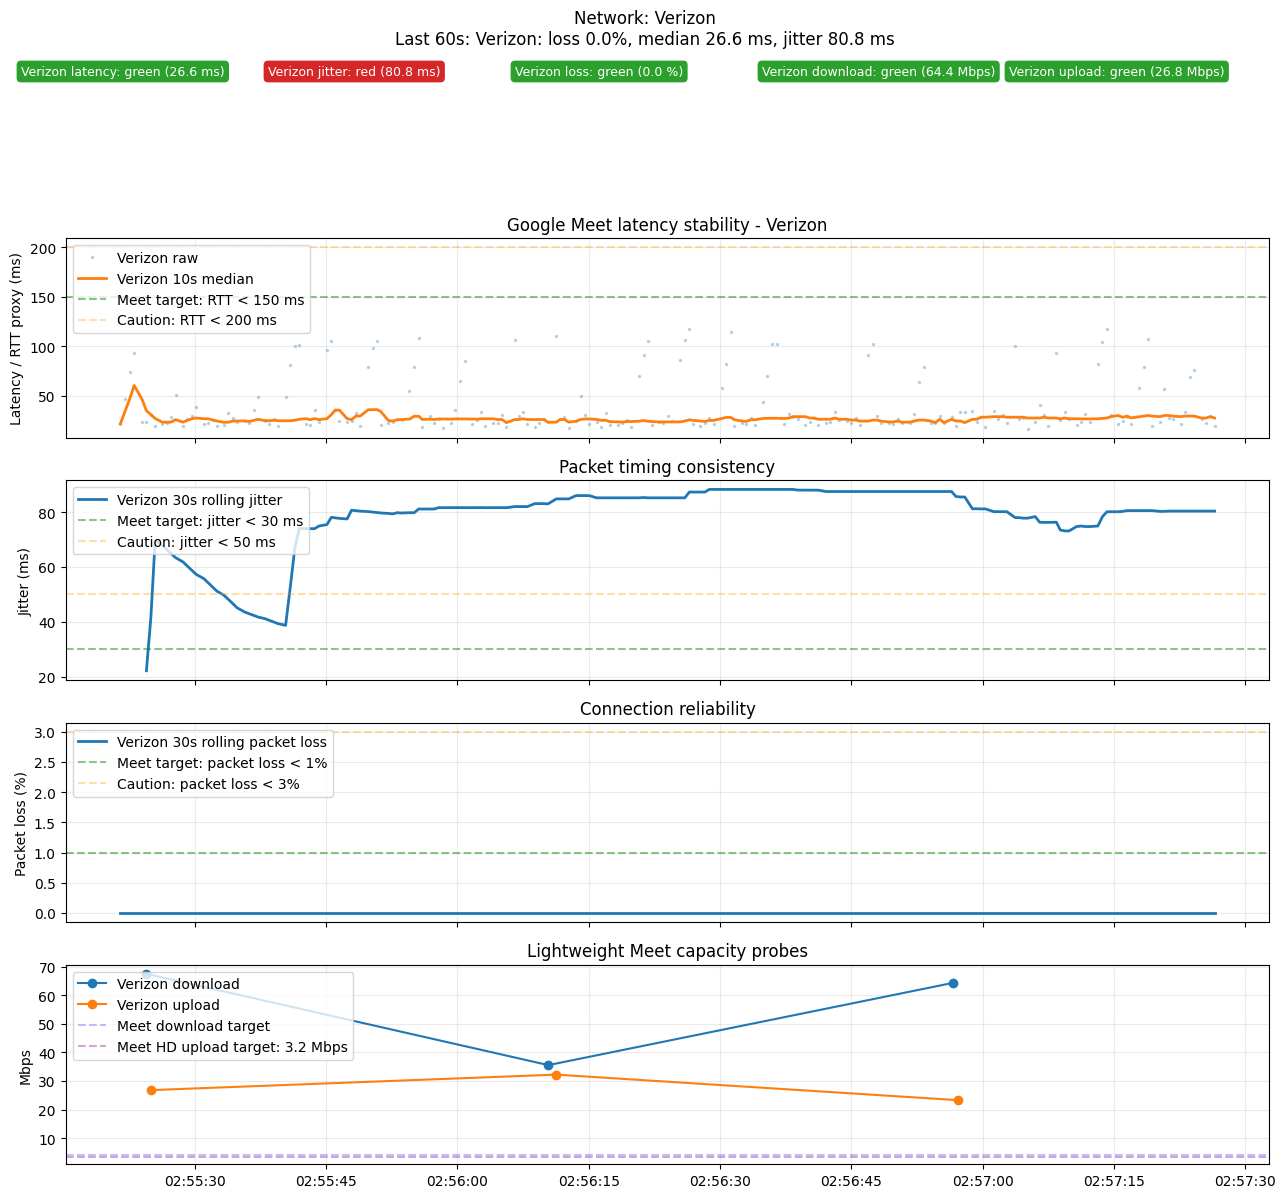

CancelledError: 

In [62]:
# Sequential example: run this once per network after connecting to that network.
network_name = network_name_widget.value.strip()
if not network_name:
    raise ValueError("Enter a network name in the widget before running the monitor.")

CONNECTIONS_TO_TEST = [
    {"name": network_name, "source_ip": None},
]

print("Testing network label:", CONNECTIONS_TO_TEST[0]["name"])

# Run for 5 minutes. Change duration_seconds as needed.
df = await run_monitor(CONNECTIONS_TO_TEST, duration_seconds=300)
summarize(df)

In [43]:
export_all_results(label=current_network_export_label())


Saved raw CSV: internet_quality_results/peanut_butter_raw_20260509_222139.csv
Saved PDF report: internet_quality_results/peanut_butter_report_20260509_222139.pdf


(PosixPath('internet_quality_results/peanut_butter_raw_20260509_222139.csv'),
 PosixPath('internet_quality_results/peanut_butter_report_20260509_222139.pdf'))

## Option B: Parallel Test

Use this only if both connections are active at the same time, for example Wi-Fi plus Ethernet, or Wi-Fi plus a tethered phone. Set each `source_ip` to the local IP address on that network.

On macOS, you can inspect interface IPs in Terminal with commands like:

```bash
ipconfig getifaddr en0
ipconfig getifaddr en1
ifconfig
```

Common examples: Wi-Fi is often `en0`; USB/iPhone tethering or Ethernet may be another `en*` interface.

In [ ]:
# Parallel example: replace these source_ip values with the local IPs for each interface.
CONNECTIONS_TO_TEST = [
    {"name": "wifi", "source_ip": "192.168.1.25"},
    {"name": "hotspot_or_ethernet", "source_ip": "172.20.10.2"},
]

# Run for 5 minutes. Comment this out until the source IPs are correct.
# df = await run_monitor(CONNECTIONS_TO_TEST, duration_seconds=300)
# summarize(df)

## Compare Saved Sequential Runs

If you ran the two networks one after another, load the CSVs and summarize them together.

,connection,meet_status,packet_loss_pct,median_latency_ms,jitter_ms,p95_latency_ms,download_median_mbps,upload_median_mbps,source_file
network_label,,,,,,,,,
peanut_butter,Peanut Butter,likely_sluggish,0.0,33.594562,83.517883,114.795808,39.365601,22.452391,peanut_butter_raw_20260509_222156.csv
verizon,Verizon,likely_sluggish,0.0,26.121417,83.711708,104.502383,64.359415,26.777732,verizon_raw_20260509_225938.csv


/var/folders/w4/414f0cw907156lyj9xcxgq280000gn/T/ipykernel_44092/976021077.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(values, labels=labels, patch_artist=True, showmeans=True)
/var/folders/w4/414f0cw907156lyj9xcxgq280000gn/T/ipykernel_44092/976021077.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(values, labels=labels, patch_artist=True, showmeans=True)
/var/folders/w4/414f0cw907156lyj9xcxgq280000gn/T/ipykernel_44092/976021077.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(values, labels=labels, patch_artist=True, showmeans=True)
/var/folders/

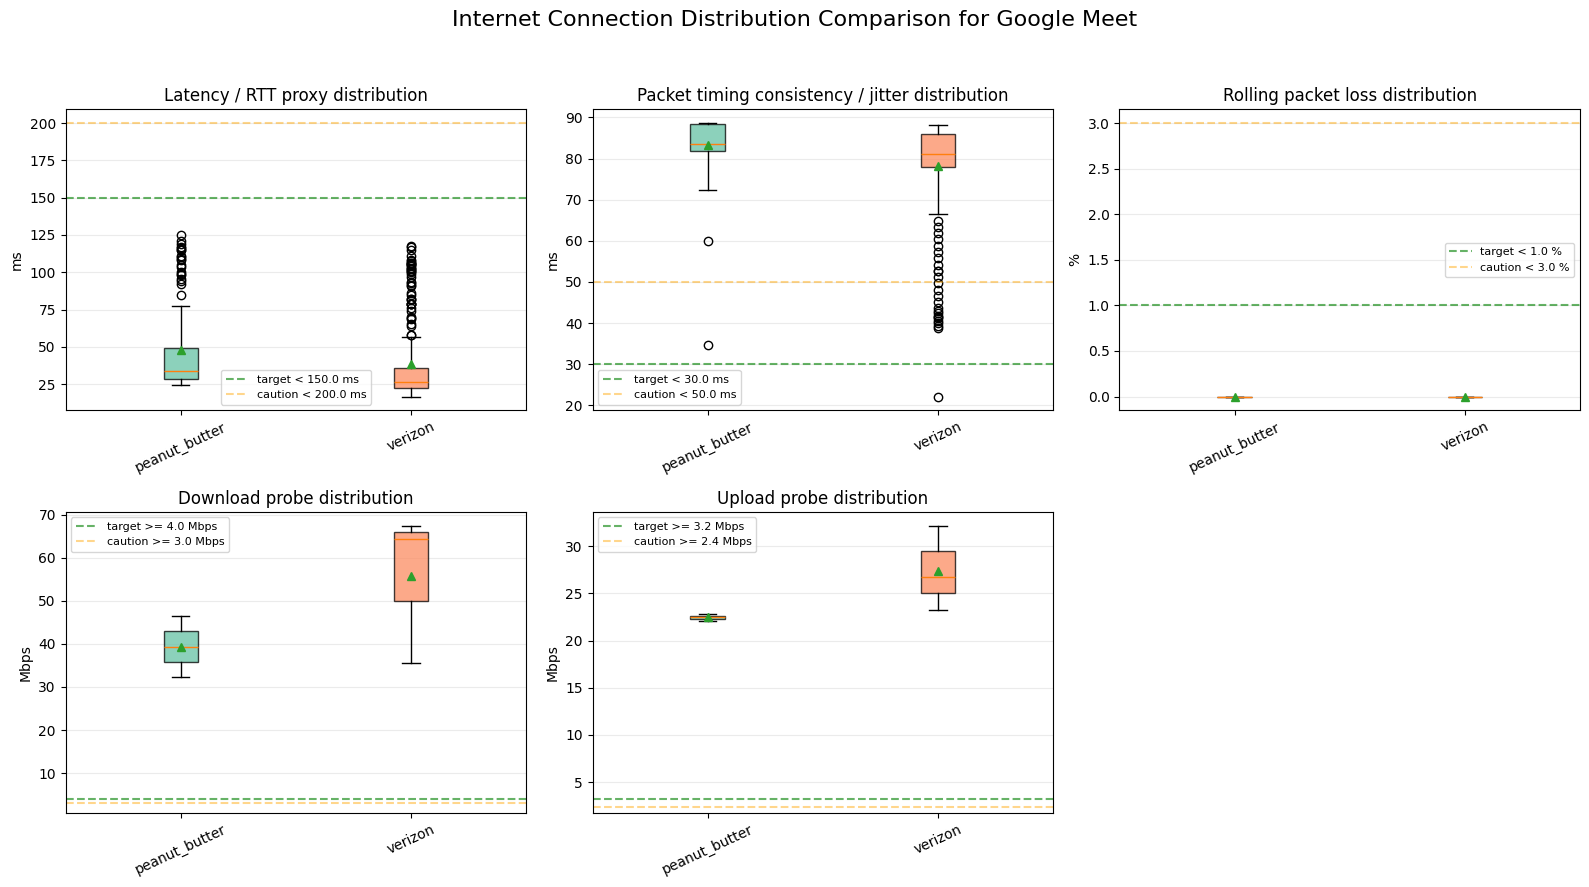

,metric,network_label,samples,median,p25,p75,p95
0,latency_ms,peanut_butter,108,33.594562,28.131219,48.993656,114.795808
1,latency_ms,verizon,214,26.121417,22.159209,35.900427,104.502383
2,jitter_ms,peanut_butter,103,83.570021,81.769380,88.461125,88.623083
3,jitter_ms,verizon,209,81.136792,77.884259,86.007875,88.244437
4,packet_loss_pct,peanut_butter,108,0.000000,0.000000,0.000000,0.000000
5,packet_loss_pct,verizon,214,0.000000,0.000000,0.000000,0.000000
6,download_mbps,peanut_butter,2,39.365601,35.846220,42.884982,45.700487
7,download_mbps,verizon,3,64.359415,49.949205,65.923672,67.175077
8,upload_mbps,peanut_butter,2,22.452391,22.264236,22.640546,22.791070
9,upload_mbps,verizon,3,26.777732,25.025215,29.493979,31.666976


network_label,peanut_butter,verizon
packet_loss_pct,0.000000,0.000000
median_latency_ms,33.594562,26.121417
jitter_ms,83.517883,83.711708
p95_latency_ms,114.795808,104.502383
download_median_mbps,39.365601,64.359415
upload_median_mbps,22.452391,26.777732


,network_label,path
1,peanut_butter,internet_quality_results/peanut_butter_raw_202...
2,verizon,internet_quality_results/verizon_raw_20260509_...


In [69]:
def meet_comparison_metric_specs():
    return [
        {
            "key": "latency_ms",
            "title": "Latency / RTT proxy distribution",
            "unit": "ms",
            "target": MEET_TARGET_LATENCY_MS,
            "caution": MEET_CAUTION_LATENCY_MS,
            "better": "lower",
        },
        {
            "key": "jitter_ms",
            "title": "Packet timing consistency / jitter distribution",
            "unit": "ms",
            "target": MEET_GOOD_JITTER_MS,
            "caution": MEET_OK_JITTER_MS,
            "better": "lower",
        },
        {
            "key": "packet_loss_pct",
            "title": "Rolling packet loss distribution",
            "unit": "%",
            "target": MEET_GOOD_LOSS_PCT,
            "caution": MEET_OK_LOSS_PCT,
            "better": "lower",
        },
        {
            "key": "download_mbps",
            "title": "Download probe distribution",
            "unit": "Mbps",
            "target": MEET_TARGET_DOWNLOAD_MBPS,
            "caution": MEET_TARGET_DOWNLOAD_MBPS * 0.75,
            "better": "higher",
        },
        {
            "key": "upload_mbps",
            "title": "Upload probe distribution",
            "unit": "Mbps",
            "target": MEET_TARGET_UPLOAD_MBPS,
            "caution": MEET_TARGET_UPLOAD_MBPS * 0.75,
            "better": "higher",
        },
    ]


def latest_raw_result_paths(result_dir="internet_quality_results"):
    result_dir = Path(result_dir)
    raw_paths = sorted(result_dir.glob("*_raw_*.csv"))
    if not raw_paths:
        return pd.DataFrame(columns=["network_label", "path", "modified_at"])

    file_index = pd.DataFrame([
        {
            "network_label": path.name.split("_raw_", 1)[0],
            "path": path,
            "modified_at": path.stat().st_mtime,
        }
        for path in raw_paths
    ])
    latest_idx = file_index.groupby("network_label")["modified_at"].idxmax()
    return file_index.loc[latest_idx].sort_values("network_label").reset_index(drop=True)


def load_latest_raw_runs(result_dir="internet_quality_results"):
    latest_paths = latest_raw_result_paths(result_dir)
    if latest_paths.empty:
        return pd.DataFrame(), latest_paths

    runs = []
    for _, row in latest_paths.iterrows():
        run_df = pd.read_csv(row["path"])
        run_df["network_label"] = row["network_label"]
        run_df["source_file"] = row["path"].name
        runs.append(run_df)

    combined = pd.concat(runs, ignore_index=True)
    combined["time"] = pd.to_datetime(combined["ts"])
    return combined, latest_paths


def build_meet_comparison_summary(combined):
    comparison_rows = []
    for network_label, run_df in combined.groupby("network_label"):
        meet_summary, latency_summary, speed_summary = summarize(run_df)
        row = meet_summary.reset_index().iloc[0].to_dict()
        row["network_label"] = network_label
        row["source_file"] = run_df["source_file"].iloc[0]
        comparison_rows.append(row)

    if not comparison_rows:
        return pd.DataFrame()
    return pd.DataFrame(comparison_rows).set_index("network_label")


def build_metric_distributions(combined, metric_specs=None):
    metric_specs = metric_specs or meet_comparison_metric_specs()
    distributions = {spec["key"]: {} for spec in metric_specs}

    for network_label, run_df in combined.groupby("network_label"):
        ping_df = run_df[run_df["metric"] == "tcp_ping"].copy()
        speed_df = run_df[run_df["metric"].isin(["download", "upload"])].copy()

        distributions["latency_ms"][network_label] = ping_df.loc[ping_df["ok"], "latency_ms"].dropna()

        quality_parts = [
            rolling_ping_quality(connection_ping_df, window="30s")
            for _, connection_ping_df in ping_df.groupby("connection")
        ]
        if quality_parts:
            quality_df = pd.concat(quality_parts)
            distributions["jitter_ms"][network_label] = quality_df["jitter_ms"].dropna()
            distributions["packet_loss_pct"][network_label] = quality_df["packet_loss_pct"].dropna()
        else:
            distributions["jitter_ms"][network_label] = pd.Series(dtype="float64")
            distributions["packet_loss_pct"][network_label] = pd.Series(dtype="float64")

        distributions["download_mbps"][network_label] = speed_df.loc[
            (speed_df["metric"] == "download") & speed_df["ok"], "mbps"
        ].dropna()
        distributions["upload_mbps"][network_label] = speed_df.loc[
            (speed_df["metric"] == "upload") & speed_df["ok"], "mbps"
        ].dropna()

    return distributions


def plot_metric_distribution_boxplots(distributions, metric_specs=None):
    metric_specs = metric_specs or meet_comparison_metric_specs()
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.ravel()

    for ax, spec in zip(axes, metric_specs):
        metric_distribution = distributions[spec["key"]]
        labels = [label for label, values in metric_distribution.items() if not values.empty]
        values = [metric_distribution[label].values for label in labels]

        if values:
            box = ax.boxplot(values, labels=labels, patch_artist=True, showmeans=True)
            for patch, color in zip(box["boxes"], plt.cm.Set2(range(len(values)))):
                patch.set_facecolor(color)
                patch.set_alpha(0.75)
        else:
            ax.text(0.5, 0.5, "No samples", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(spec["title"])
        ax.set_ylabel(spec["unit"])
        ax.grid(True, axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=25)

        target_label = f"target {'<' if spec['better'] == 'lower' else '>='} {spec['target']:.1f} {spec['unit']}"
        caution_label = f"caution {'<' if spec['better'] == 'lower' else '>='} {spec['caution']:.1f} {spec['unit']}"
        ax.axhline(spec["target"], color="green", linestyle="--", alpha=0.6, label=target_label)
        ax.axhline(spec["caution"], color="orange", linestyle="--", alpha=0.45, label=caution_label)
        ax.legend(fontsize=8)

    for ax in axes[len(metric_specs):]:
        ax.axis("off")

    fig.suptitle("Internet Connection Distribution Comparison for Google Meet", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def summarize_metric_distributions(distributions, metric_specs=None):
    metric_specs = metric_specs or meet_comparison_metric_specs()
    rows = []
    for spec in metric_specs:
        for network_label, values in distributions[spec["key"]].items():
            rows.append({
                "metric": spec["key"],
                "network_label": network_label,
                "samples": len(values),
                "median": values.median() if len(values) else math.nan,
                "p25": values.quantile(0.25) if len(values) else math.nan,
                "p75": values.quantile(0.75) if len(values) else math.nan,
                "p95": values.quantile(0.95) if len(values) else math.nan,
            })
    return pd.DataFrame(rows)


def display_meet_connection_comparison(result_dir="internet_quality_results"):
    combined, latest_paths = load_latest_raw_runs(result_dir)
    if combined.empty:
        print("No raw CSVs found yet. Export each run first.")
        return None

    comparison = build_meet_comparison_summary(combined)
    display_columns = [
        "connection",
        "meet_status",
        "packet_loss_pct",
        "median_latency_ms",
        "jitter_ms",
        "p95_latency_ms",
        "download_median_mbps",
        "upload_median_mbps",
        "source_file",
    ]
    display(comparison[[column for column in display_columns if column in comparison.columns]])

    metric_specs = meet_comparison_metric_specs()
    distributions = build_metric_distributions(combined, metric_specs)
    fig = plot_metric_distribution_boxplots(distributions, metric_specs)
    display(fig)
    plt.close(fig)

    display(summarize_metric_distributions(distributions, metric_specs))

    numeric_columns = [
        "packet_loss_pct",
        "median_latency_ms",
        "jitter_ms",
        "p95_latency_ms",
        "download_median_mbps",
        "upload_median_mbps",
    ]
    side_by_side = comparison[[column for column in numeric_columns if column in comparison.columns]].T
    display(side_by_side)
    display(latest_paths[["network_label", "path"]])

    return {
        "combined": combined,
        "latest_paths": latest_paths,
        "comparison": comparison,
        "distributions": distributions,
    }


comparison_results = display_meet_connection_comparison()